In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [32]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

training_set = train_datagen.flow_from_directory(
    '/mnt/d/Medical-Image-Diagnosis/data/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 4173 images belonging to 2 classes.


Test set prep

In [33]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow_from_directory(
    '/mnt/d/Medical-Image-Diagnosis/data/chest_xray/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


Validation set prep

In [34]:
validation_set = train_datagen.flow_from_directory(
    '/mnt/d/Medical-Image-Diagnosis/data/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1043 images belonging to 2 classes.


In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_set.classes),
    y=training_set.classes
)

class_weights = dict(enumerate(class_weights))

print("Class indices:", training_set.class_indices)
print("Class weights:", class_weights)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


BUILDING CNN

In [36]:
cnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [37]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

In [39]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

BALANCING

In [40]:
history = cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/25


I0000 00:00:1788718081.414636    2863 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11518__.69
I0000 00:00:1788718086.078094    2863 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 27/131 ━━━━━━━━━━━━━━━━━━━━ 53s 516ms/step - accuracy: 0.7616 - loss: 0.4923

I0000 00:00:1788718104.516246    2863 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11518__.69


131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 753ms/step - accuracy: 0.8414 - loss: 0.3559 - val_accuracy: 0.7430 - val_loss: 0.7985
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 680ms/step - accuracy: 0.8910 - loss: 0.2539 - val_accuracy: 0.7430 - val_loss: 1.6343
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 663ms/step - accuracy: 0.8986 - loss: 0.2254 - val_accuracy: 0.7430 - val_loss: 1.7471
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 641ms/step - accuracy: 0.9168 - loss: 0.2049 - val_accuracy: 0.7430 - val_loss: 1.9209
Epoch 5/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 641ms/step - accuracy: 0.9248 - loss: 0.1792 - val_accuracy: 0.9070 - val_loss: 0.1966
Epoch 6/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 632ms/step - accuracy: 0.9269 - loss: 0.1729 - val_accuracy: 0.8370 - val_loss: 0.3224
Epoch 7/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 934ms/step - accuracy: 0.9276 - loss: 0.1736 - val_accuracy: 0.6999 - val_loss: 0.7823
Epoch 8/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9387 - loss: 0.1503 - val

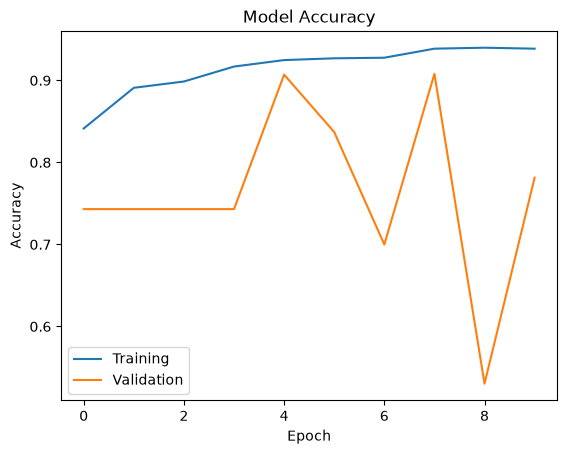

In [41]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])
plt.show()



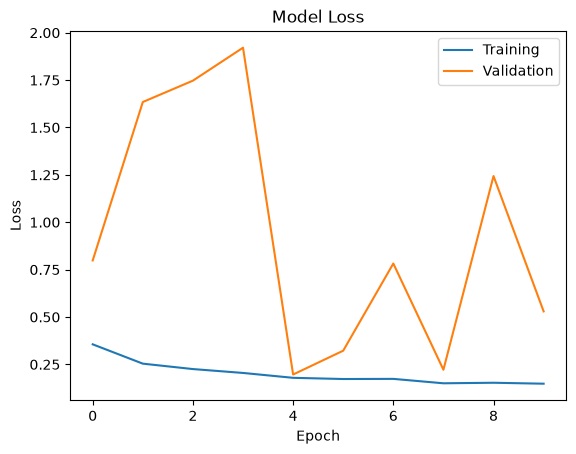

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()


In [43]:
test_loss, test_accuracy = cnn.evaluate(test_set)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 935ms/step - accuracy: 0.8542 - loss: 0.3215
Test Loss: 0.32154542207717896
Test Accuracy: 0.8541666865348816


In [44]:
import numpy as np

test_set.reset()

predictions = cnn.predict(test_set)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_set.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step


In [45]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(true_classes, predicted_classes)
print(cm)

[[173  61]
 [ 30 360]]


In [46]:
from sklearn.metrics import classification_report
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.85      0.74      0.79       234
   PNEUMONIA       0.86      0.92      0.89       390

    accuracy                           0.85       624
   macro avg       0.85      0.83      0.84       624
weighted avg       0.85      0.85      0.85       624



In [47]:
print(predictions[:20].flatten())

print("Minimum:", predictions.min())
print("Maximum:", predictions.max())
print("Mean:", predictions.mean())

[0.09907656 0.15468447 0.06513738 0.18757461 0.07979149 0.4660462
 0.09750747 0.06680632 0.10914156 0.05796896 0.06356973 0.179068
 0.11211587 0.13611601 0.20932631 0.30063918 0.93792707 0.09395707
 0.04538713 0.09023491]
Minimum: 0.024411606
Maximum: 0.9992495
Mean: 0.67830706


In [48]:
cnn.save("/mnt/d/Medical-Image-Diagnosis/models/pneumonia_scratch.keras")
print("Model saved successfully")

Model saved successfully
